# Exploratory Data Analysis (EDA)

In this notebook, we explore the dataset to understand it.

We will:
- Load the dataset from the project folder
- Check size and structure
- Inspect columns and data types
- Find missing values and duplicates
- Analyze numerical and categorical features
- Study the target variable
- Detect outliers and correlations

This step is only for understanding the data.


## Load dataset

The dataset is stored in the same project folder as this notebook.
We load it directly using its filename and preview the first rows.


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset (same folder as notebook)
df = pd.read_csv("student_depression_dataset.csv")

# Preview
df.head()


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


## Dataset shape

We check:
- Number of rows
- Number of columns


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 27901
Columns: 18


## Columns and data types

We inspect:
- Column names
- Data types
- Non-null counts


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

## Sample records

We view:
- First rows
- Last rows
- Random rows


In [5]:
display(df.head())
display(df.tail())
display(df.sample(5, random_state=42))


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1
27900,140699,Male,27.0,Patna,Student,4.0,0.0,9.24,1.0,0.0,'Less than 5 hours',Healthy,BCA,Yes,2.0,3.0,Yes,1


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
19981,101205,Female,29.0,Kalyan,Student,2.0,0.0,8.53,3.0,0.0,'More than 8 hours',Healthy,B.Arch,No,10.0,5.0,No,0
16551,83727,Male,28.0,Srinagar,Student,2.0,0.0,5.57,5.0,0.0,'7-8 hours',Unhealthy,M.Tech,Yes,3.0,1.0,Yes,0
7640,38395,Male,34.0,Varanasi,Student,3.0,0.0,5.12,4.0,0.0,'More than 8 hours',Moderate,M.Pharm,Yes,4.0,3.0,Yes,0
21266,107434,Male,21.0,Mumbai,Student,5.0,0.0,8.95,2.0,0.0,'Less than 5 hours',Unhealthy,B.Pharm,Yes,8.0,1.0,No,1
15759,79662,Male,25.0,Visakhapatnam,Student,5.0,0.0,7.87,2.0,0.0,'Less than 5 hours',Healthy,B.Ed,No,0.0,3.0,No,1


## Summary statistics

This shows:
- Mean
- Median
- Standard deviation
- Min and max values


In [6]:
df.describe()


,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


## Missing values

We calculate:
- Number of missing values
- Percentage of missing values


In [46]:
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(2)
})

missing_df[missing_df["missing_count"] > 0]
missing_count


Age                                      0
Academic Pressure                        0
CGPA                                     0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
Gender_Female                            0
Gender_Male                              0
City_Agra                                0
City_Ahmedabad                           0
City_Bangalore                           0
City_Bhopal                              0
City_Chennai                             0
City_Delhi                               0
City_Faridabad                           0
City_Ghaziabad                           0
City_Hyderabad                           0
City_Indore

## Duplicate rows

We check if the dataset contains duplicate rows.


In [8]:
df.duplicated().sum()


np.int64(0)

## Unique values per column

This helps identify:
- ID-like columns
- Binary features
- Categorical features


In [9]:
df.nunique().sort_values(ascending=False)


id                                       27901
CGPA                                       332
City                                        52
Age                                         34
Degree                                      28
Profession                                  14
Work/Study Hours                            13
Financial Stress                             6
Academic Pressure                            6
Study Satisfaction                           6
Sleep Duration                               5
Job Satisfaction                             5
Dietary Habits                               4
Work Pressure                                3
Gender                                       2
Have you ever had suicidal thoughts ?        2
Family History of Mental Illness             2
Depression                                   2
dtype: int64

## Target variable

If this dataset is supervised:
- We identify the target column
- Check class balance


In [10]:
possible_targets = [c for c in df.columns if "depress" in c.lower()]
possible_targets


['Depression']

In [11]:
TARGET_COL = possible_targets[0] if possible_targets else None
TARGET_COL


'Depression'

In [12]:
if TARGET_COL:
    display(df[TARGET_COL].value_counts())
    display(df[TARGET_COL].value_counts(normalize=True) * 100)
else:
    print("Target column not detected automatically")


Depression
1    16336
0    11565
Name: count, dtype: int64

Depression
1    58.549873
0    41.450127
Name: proportion, dtype: float64

## Categorical features

We count values for categorical columns to find:
- Inconsistent labels
- Rare categories


In [13]:
cat_cols = [
    "Gender",
    "City",
    "Profession",
    "Academic Pressure",
    "Work Pressure",
    "Study Satisfaction",
    "Job Satisfaction",
    "Sleep Duration",
    "Dietary Habits",
    "Degree",
    "Have you ever had suicidal thoughts ?",
    "Work/Study Hours",
    "Financial Stress",
    "Family History of Mental Illness",
    "Depression"
]



for col in cat_cols:
    print(f"\n{col}")
    display(df[col].value_counts())




Gender


Gender
Male      15547
Female    12354
Name: count, dtype: int64


City


City
Kalyan                  1570
Srinagar                1372
Hyderabad               1340
Vasai-Virar             1290
Lucknow                 1155
Thane                   1139
Ludhiana                1111
Agra                    1094
Surat                   1078
Kolkata                 1066
Jaipur                  1036
Patna                   1007
Visakhapatnam            969
Pune                     968
Ahmedabad                951
Bhopal                   934
Chennai                  885
Meerut                   825
Rajkot                   816
Delhi                    768
Bangalore                767
Ghaziabad                745
Mumbai                   699
Vadodara                 694
Varanasi                 685
Nagpur                   651
Indore                   643
Kanpur                   609
Nashik                   547
Faridabad                461
Saanvi                     2
Bhavna                     2
City                       2
Harsha                     2
'Less Del


Profession


...

Financial Stress
5.0    6715
4.0    5775
3.0    5226
1.0    5121
2.0    5061
?         3
Name: count, dtype: int64


Family History of Mental Illness


Family History of Mental Illness
No     14398
Yes    13503
Name: count, dtype: int64


Depression


Depression
1    16336
0    11565
Name: count, dtype: int64

## distributions

Histograms help us understand:
- Data spread
- Skewness
- Possible outliers


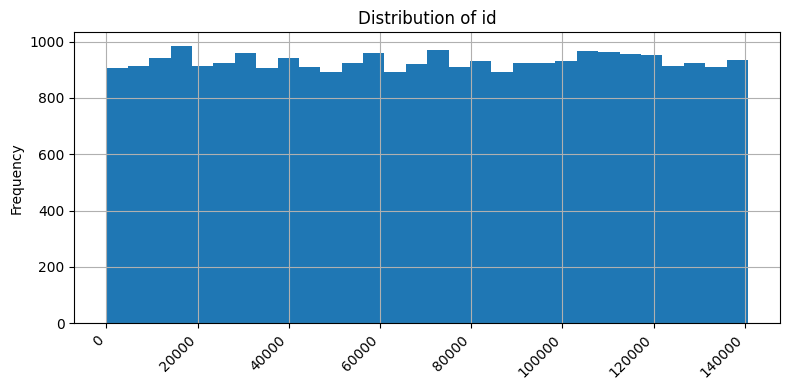

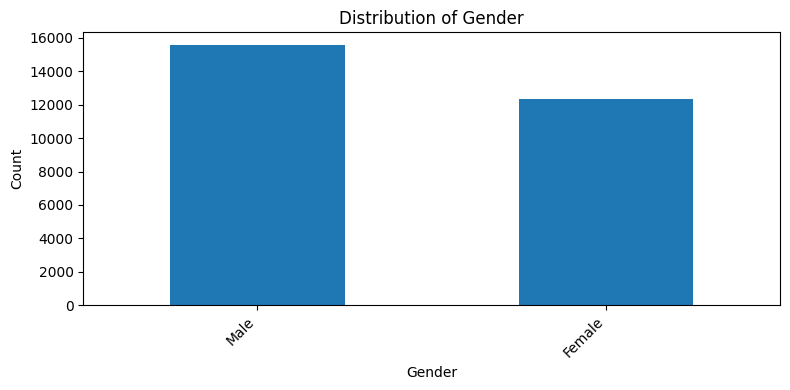

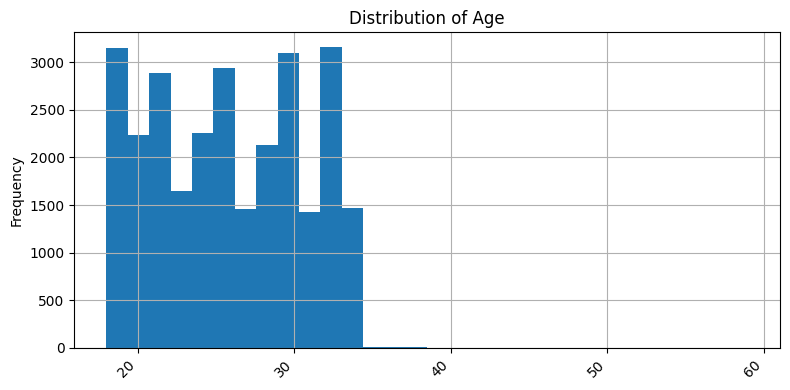

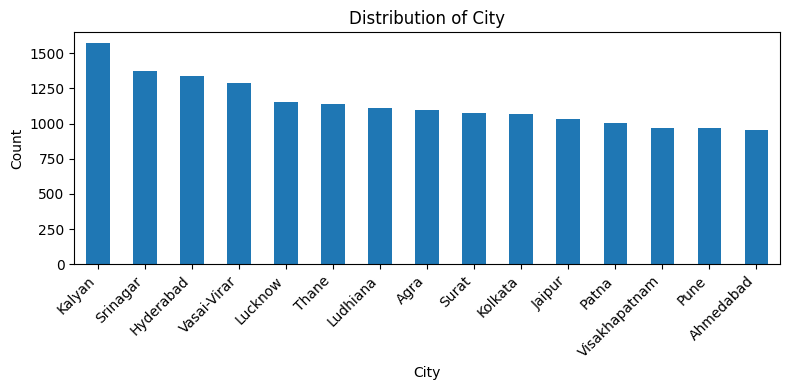

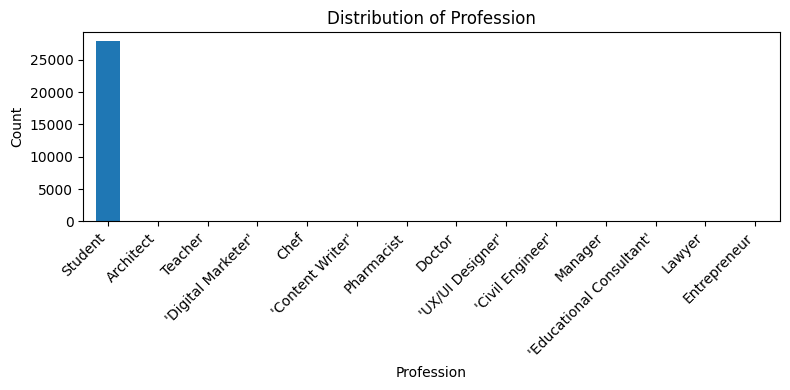

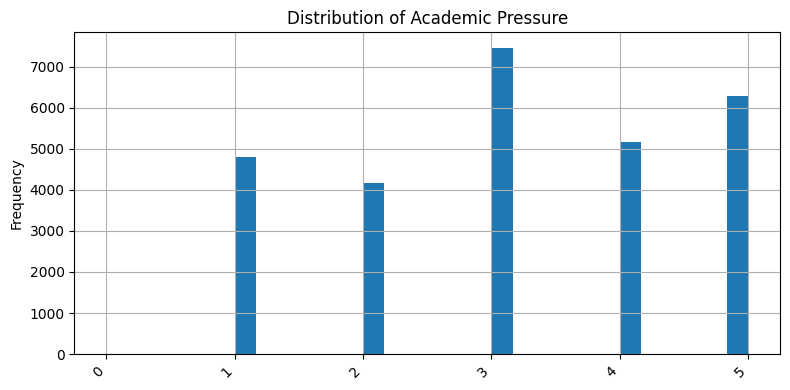

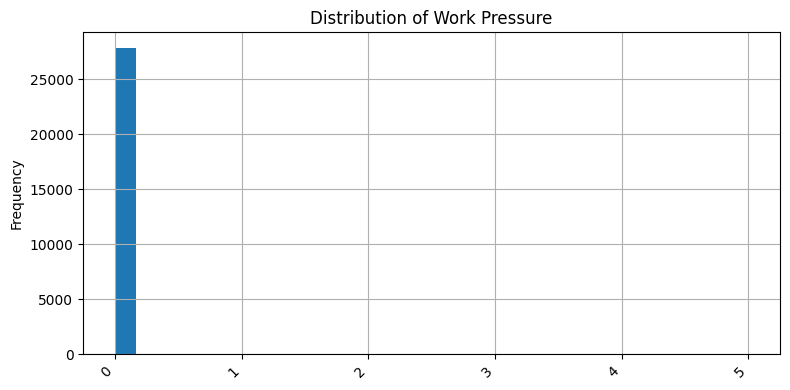

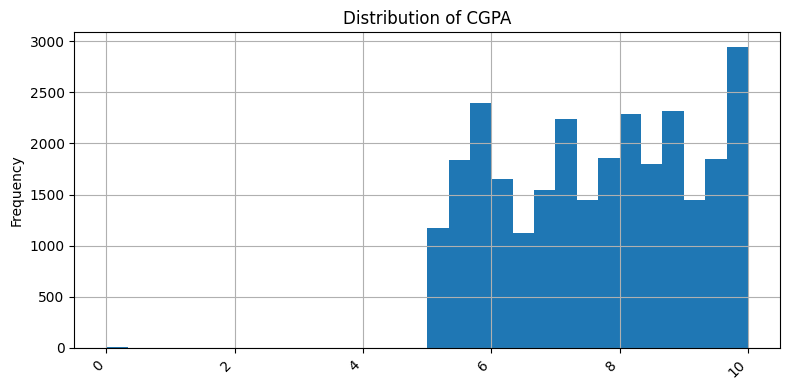

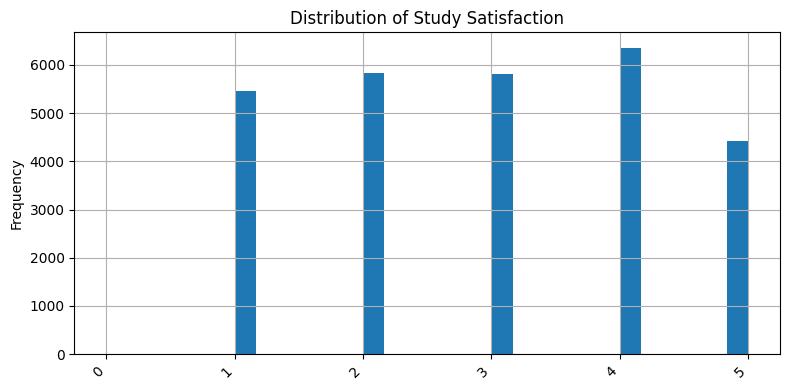

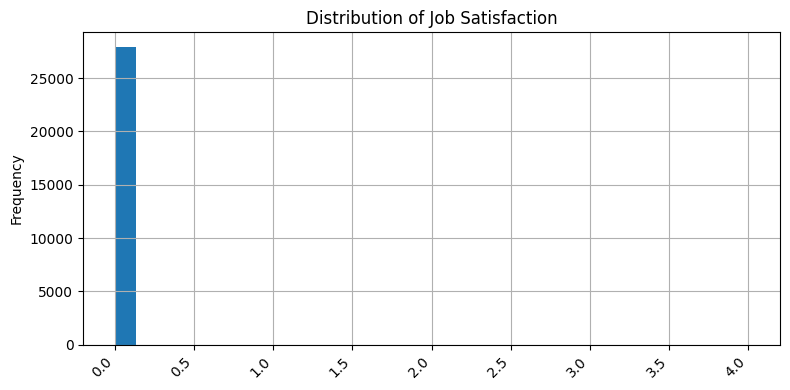

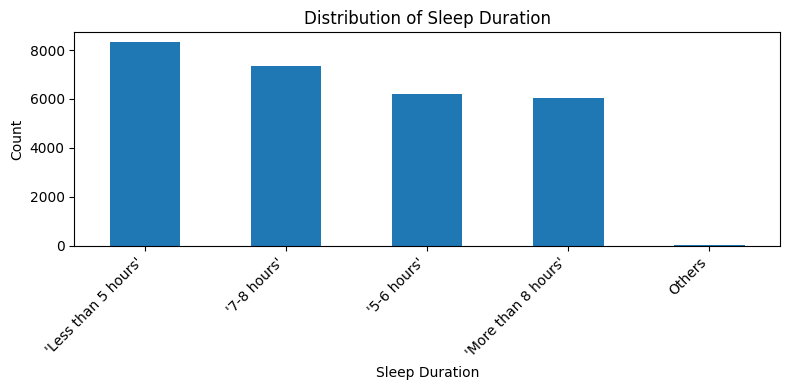

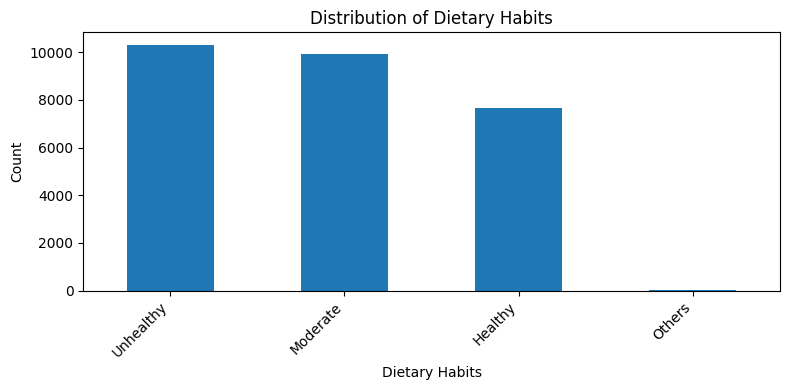

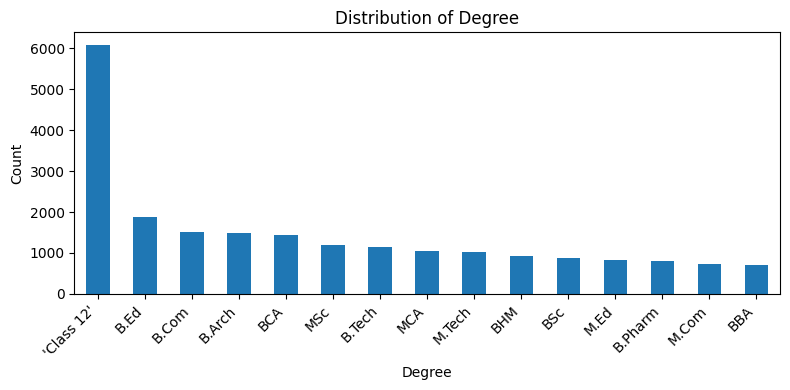

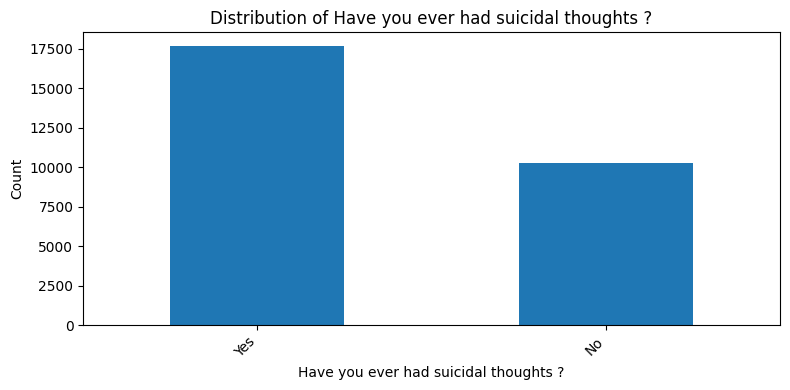

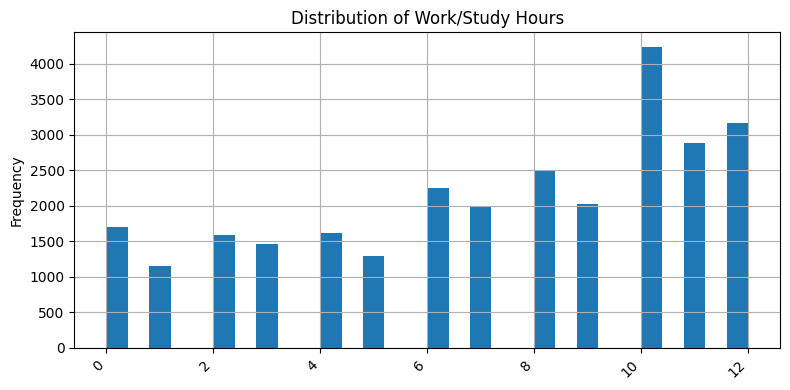

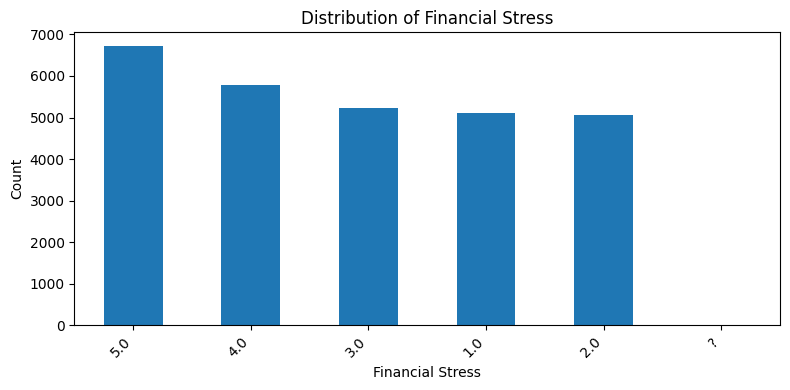

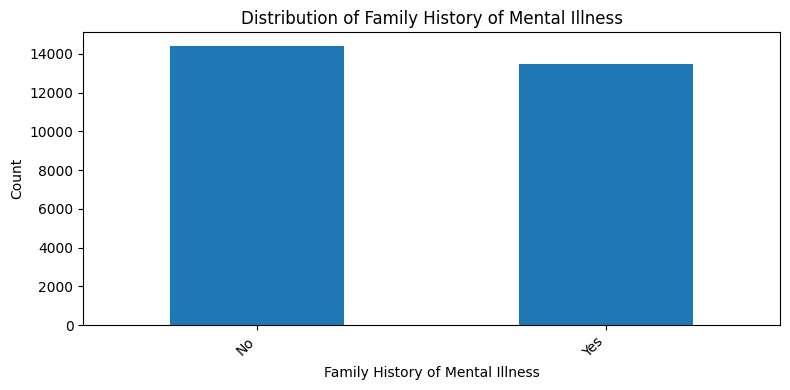

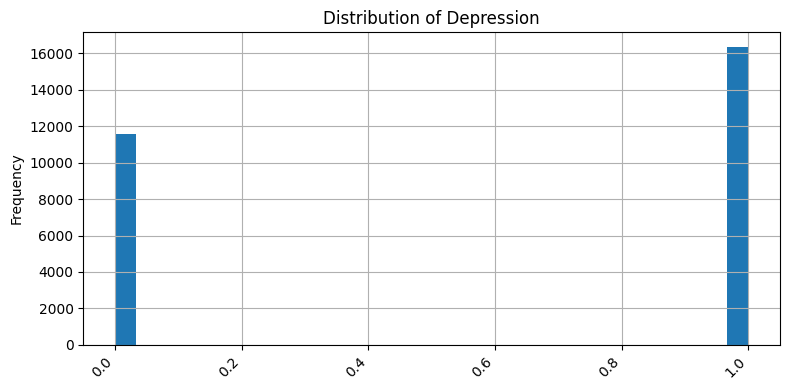

In [14]:

for col in df.columns:
    plt.figure(figsize=(8, 4))

    if df[col].dtype == "object":
        # Categorical: bar plot
        df[col].value_counts().head(15).plot(kind="bar")
        plt.ylabel("Count")
    else:
        # Numeric: histogram
        df[col].hist(bins=30)
        plt.ylabel("Frequency")

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## Outlier detection

We use the IQR method to detect outliers in numeric features.


In [15]:
# Select numerical columns
num_cols = df.select_dtypes(include="number").columns

outliers = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers.append((col, count))

# Display outlier counts
pd.DataFrame(
    outliers,
    columns=["column", "outlier_count"]
).sort_values("outlier_count", ascending=False)


,column,outlier_count
1,Age,12
4,CGPA,9
6,Job Satisfaction,8
3,Work Pressure,3
0,id,0
2,Academic Pressure,0
5,Study Satisfaction,0
7,Work/Study Hours,0
8,Depression,0


## Inspect "Others" in Sleep Duration

We check the rows where `Sleep Duration` is labeled as `Others`.

This helps us understand:
- What these rows look like
- Whether they should be cleaned, mapped, or removed


In [16]:
# Filter rows where Sleep Duration is 'Others'
sleep_others = df[df["Sleep Duration"] == "Others"]

# Number of such rows
print("Number of 'Others' rows:", sleep_others.shape[0])

# Display them
display(sleep_others)


Number of 'Others' rows: 18


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
1963,10030,Female,30.0,Ludhiana,Student,3.0,0.0,5.42,2.0,0.0,Others,Unhealthy,B.Ed,Yes,1.0,2.0,No,0
3807,19051,Female,18.0,Agra,Student,3.0,0.0,6.03,4.0,0.0,Others,Unhealthy,BA,Yes,12.0,5.0,No,1
3984,19915,Female,27.0,Ludhiana,Student,4.0,0.0,5.08,5.0,0.0,Others,Healthy,M.Tech,Yes,8.0,5.0,Yes,1
4535,22742,Female,22.0,Srinagar,Student,4.0,0.0,6.92,3.0,0.0,Others,Moderate,MCA,Yes,3.0,3.0,Yes,1
5526,27865,Female,31.0,Delhi,Student,2.0,0.0,7.27,5.0,0.0,Others,Healthy,B.Arch,No,3.0,1.0,No,0
5786,29050,Male,23.0,Mumbai,Student,5.0,0.0,8.52,4.0,0.0,Others,Moderate,BE,Yes,12.0,4.0,Yes,1
6740,33836,Male,20.0,Vasai-Virar,Student,3.0,0.0,6.37,2.0,0.0,Others,Unhealthy,BSc,No,10.0,1.0,No,0
7696,38701,Male,31.0,Kalyan,Student,3.0,0.0,8.21,4.0,0.0,Others,Moderate,BA,No,2.0,3.0,No,0
7875,39566,Female,28.0,Visakhapatnam,Student,4.0,0.0,6.38,5.0,0.0,Others,Moderate,M.Ed,No,8.0,3.0,No,0
12933,65456,Male,28.0,Nagpur,Student,2.0,0.0,7.85,4.0,0.0,Others,Unhealthy,BA,Yes,10.0,4.0,No,1


## Handle "Others" in Sleep Duration

The value `Others` does not represent a clear number of hours.

We treat it as missing data:
- Replace `Others` with NaN
- Keep the rows
- Handle missing values later using imputation

This avoids guessing and keeps data quality high.


In [17]:
import numpy as np

# Replace 'Others' with NaN
df["Sleep Duration"] = df["Sleep Duration"].replace("Others", np.nan)

# Check result
print("Missing values in Sleep Duration:")
print(df["Sleep Duration"].isna().sum())

# Confirm unique values
df["Sleep Duration"].value_counts(dropna=False)


Missing values in Sleep Duration:
18


Sleep Duration
'Less than 5 hours'    8310
'7-8 hours'            7346
'5-6 hours'            6183
'More than 8 hours'    6044
NaN                      18
Name: count, dtype: int64

## Inspect "Others" in Dietary Habits

We print the rows where `Dietary Habits` is labeled as `Others`.

This helps us verify:
- How many rows are affected
- Whether the rows look valid


In [18]:
# Filter rows where Dietary Habits is 'Others'
diet_others = df[df["Dietary Habits"] == "Others"]

# Number of rows
print("Number of 'Others' rows:", diet_others.shape[0])

# Display rows
display(diet_others)


Number of 'Others' rows: 12


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
5684,28610,Male,23.0,Meerut,Student,3.0,0.0,9.98,5.0,0.0,'Less than 5 hours',Others,B.Com,Yes,4.0,5.0,No,1
6892,34623,Male,18.0,Vadodara,Student,1.0,0.0,6.05,5.0,0.0,'7-8 hours',Others,'Class 12',No,4.0,4.0,No,0
8263,41636,Female,21.0,Jaipur,Student,2.0,0.0,7.28,4.0,0.0,'Less than 5 hours',Others,B.Pharm,Yes,0.0,3.0,Yes,0
8456,42616,Female,32.0,Ahmedabad,Student,4.0,0.0,9.54,4.0,0.0,'5-6 hours',Others,B.Ed,Yes,4.0,2.0,No,1
11746,59350,Male,34.0,Agra,Student,5.0,0.0,9.04,1.0,0.0,'More than 8 hours',Others,B.Tech,Yes,4.0,5.0,Yes,1
12763,64565,Female,23.0,Bangalore,Student,2.0,0.0,6.91,5.0,0.0,'5-6 hours',Others,M.Pharm,No,6.0,3.0,No,1
13758,69649,Male,34.0,Ahmedabad,Student,5.0,0.0,8.24,5.0,0.0,'5-6 hours',Others,MCA,Yes,11.0,1.0,Yes,1
14504,73210,Male,26.0,Indore,Student,1.0,0.0,7.49,2.0,0.0,'Less than 5 hours',Others,LLB,Yes,6.0,4.0,No,0
15087,76041,Female,27.0,Lucknow,Student,5.0,0.0,5.82,3.0,0.0,'Less than 5 hours',Others,BSc,Yes,7.0,1.0,No,1
22515,113519,Male,30.0,Ghaziabad,Student,5.0,0.0,5.99,2.0,0.0,'7-8 hours',Others,M.Ed,Yes,7.0,4.0,No,1


## Convert "Others" to NaN in Dietary Habits

The value `Others` does not represent a valid dietary level.

We replace it with NaN and keep the rows.
Missing values will be handled later.


In [19]:
import numpy as np

df["Dietary Habits"] = df["Dietary Habits"].replace("Others", np.nan)

# Verify
print("Missing values in Dietary Habits:", df["Dietary Habits"].isna().sum())
df["Dietary Habits"].value_counts(dropna=False)


Missing values in Dietary Habits: 12


Dietary Habits
Unhealthy    10317
Moderate      9921
Healthy       7651
NaN             12
Name: count, dtype: int64

## Inspect "Others" in Degree

Before changing the data, we inspect the rows where
`Degree` is equal to `Others`.

This helps us:
- See how many rows are affected
- Verify that other feature values look valid
- Make a safe decision before cleaning


In [20]:
# Filter rows where Degree is NaN
degree_others = df[df["Degree"].isna()]

# Number of affected rows
print("Number of 'Others' in Degree:", degree_others.shape[0])

# Display the rows
display(degree_others)


Number of 'Others' in Degree: 0


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression


## Convert "Others" to NaN in Degree

The value `Others` does not belong to the ordered education scale.
We treat it as unknown.

We replace `Others` with NaN before ordinal encoding.


In [21]:

# Replace 'Others' with NaN in Degree
df["Degree"] = df["Degree"].replace("Others", np.nan)

# Verify
print("Number of NaNs in Degree:", df["Degree"].isna().sum())
df["Degree"].value_counts(dropna=False)


Number of NaNs in Degree: 35


Degree
'Class 12'    6080
B.Ed          1867
B.Com         1506
B.Arch        1478
BCA           1433
MSc           1190
B.Tech        1152
MCA           1044
M.Tech        1022
BHM            925
BSc            888
M.Ed           821
B.Pharm        810
M.Com          734
BBA            696
MBBS           696
LLB            671
BE             613
BA             600
M.Pharm        582
MD             572
MBA            562
MA             544
PhD            522
LLM            482
MHM            191
ME             185
NaN             35
Name: count, dtype: int64

## Inspect "?" in Financial Stress

The value `?` does not represent a numeric stress level.

We first print the rows where `Financial Stress` is `?`
to understand how many rows are affected and inspect them.


In [22]:
# Filter rows where Financial Stress is '?'
fs_unknown = df[df["Financial Stress"] == "?"]

# Number of affected rows
print("Number of '?' rows:", fs_unknown.shape[0])

# Display rows
display(fs_unknown)


Number of '?' rows: 3


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
4458,22377,Female,32.0,Varanasi,Student,3.0,0.0,5.64,1.0,0.0,'5-6 hours',Healthy,BCA,No,12.0,?,No,1
13596,68910,Male,29.0,Hyderabad,Student,2.0,0.0,8.94,3.0,0.0,'Less than 5 hours',Unhealthy,B.Ed,No,12.0,?,Yes,0
19266,97610,Female,20.0,Kolkata,Student,1.0,0.0,6.83,1.0,0.0,'5-6 hours',Healthy,MBBS,No,9.0,?,Yes,0


In [23]:
df["Degree"].value_counts(dropna=False)


Degree
'Class 12'    6080
B.Ed          1867
B.Com         1506
B.Arch        1478
BCA           1433
MSc           1190
B.Tech        1152
MCA           1044
M.Tech        1022
BHM            925
BSc            888
M.Ed           821
B.Pharm        810
M.Com          734
BBA            696
MBBS           696
LLB            671
BE             613
BA             600
M.Pharm        582
MD             572
MBA            562
MA             544
PhD            522
LLM            482
MHM            191
ME             185
NaN             35
Name: count, dtype: int64

In [24]:
degree_others = df[df["Degree"] == "Others"]

print("Number of 'Others' in Degree:", degree_others.shape[0])
display(degree_others)


Number of 'Others' in Degree: 0


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression


## Clean Financial Stress column

We replace `?` with NaN and convert the column to numeric.

This keeps the rows and prepares the feature for modeling.
Missing values will be handled later.


In [25]:
import numpy as np

# Replace '?' with NaN
df["Financial Stress"] = df["Financial Stress"].replace("?", np.nan)

# Convert to numeric
df["Financial Stress"] = pd.to_numeric(df["Financial Stress"])

# Verify result
print("Missing values in Financial Stress:", df["Financial Stress"].isna().sum())
df["Financial Stress"].value_counts(dropna=False).sort_index()


Missing values in Financial Stress: 3


Financial Stress
1.0    5121
2.0    5061
3.0    5226
4.0    5775
5.0    6715
NaN       3
Name: count, dtype: int64

# ***Initial insights and anomalies***



# Part 2: Data Preprocessing & Feature Engineering

In this part, we prepare the dataset for machine learning.

So far, we explored and cleaned the data.
Now we will:
- Remove unnecessary columns
- Encode categorical and binary features
- Imputing missing values
- Prepare features (X) and target (y)
- Make the data ready for model training


## Drop ID column

The `id` column is only an identifier.
It does not contain useful information for prediction.

We remove it to prevent noise and data leakage.


In [26]:
# Drop the id column
df = df.drop(columns=["id"])

# Verify
print("Columns after dropping id:")
df.columns.tolist()


Columns after dropping id:


['Gender',
 'Age',
 'City',
 'Profession',
 'Academic Pressure',
 'Work Pressure',
 'CGPA',
 'Study Satisfaction',
 'Job Satisfaction',
 'Sleep Duration',
 'Dietary Habits',
 'Degree',
 'Have you ever had suicidal thoughts ?',
 'Work/Study Hours',
 'Financial Stress',
 'Family History of Mental Illness',
 'Depression']

## Drop low-information columns

Some features have almost no variability or are extremely imbalanced.
Such columns do not add useful information for machine learning models
and may even hurt performance.

We drop the following columns:
- Profession
- Work Pressure
- Job Satisfaction


In [27]:
# Drop low-information columns
cols_to_drop = ["Profession", "Work Pressure", "Job Satisfaction"]

df.drop(columns=cols_to_drop, inplace=True)

# Verify remaining columns
df.columns.to_list()


['Gender',
 'Age',
 'City',
 'Academic Pressure',
 'CGPA',
 'Study Satisfaction',
 'Sleep Duration',
 'Dietary Habits',
 'Degree',
 'Have you ever had suicidal thoughts ?',
 'Work/Study Hours',
 'Financial Stress',
 'Family History of Mental Illness',
 'Depression']

## Encode binary (Yes / No) columns

Some columns contain binary values like `Yes` and `No`.
Machine learning models work better with numbers.

We convert:
- Yes → 1
- No → 0

This keeps the meaning and makes the data ML-ready.


In [28]:
# Columns with Yes / No values
binary_cols = [
    "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness"
]

# Map Yes -> 1, No -> 0
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

# Verify result
for col in binary_cols:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False))



Have you ever had suicidal thoughts ?


Have you ever had suicidal thoughts ?
1    17656
0    10245
Name: count, dtype: int64


Family History of Mental Illness


Family History of Mental Illness
0    14398
1    13503
Name: count, dtype: int64

## Ordinal feature mapping

Ordinal features have a natural order.
We convert them into numeric values while preserving this order.

In this step, we map:
- Sleep Duration
- Dietary Habits
- Degree


##  Map Sleep Duration to ordinal values

The `Sleep Duration` column may already be numeric from previous steps,
so `.str` will fail.

We convert it safely to string only for cleaning, while keeping NaN values,
then apply the mapping again.


In [29]:

# Convert to string safely (keep NaN)
sleep_raw = df["Sleep Duration"].copy()
sleep_clean = sleep_raw.astype("string")  # pandas StringDtype keeps <NA>
sleep_clean = sleep_clean.str.strip().str.replace("'", "", regex=False)

# Map sleep categories to hours
sleep_mapping = {
    "Less than 5 hours": 0,
    "5-6 hours": 1,
    "7-8 hours": 2,
    "More than 8 hours": 3
}

df["Sleep Duration"] = sleep_clean.map(sleep_mapping)

# Verify
df["Sleep Duration"].value_counts(dropna=False)


Sleep Duration
0.0    8310
2.0    7346
1.0    6183
3.0    6044
NaN      18
Name: count, dtype: int64

## Map Dietary Habits to ordinal values

Dietary Habits has a natural order:
Unhealthy < Moderate < Healthy

We convert these categories into numeric values
and then check the distribution after mapping.


> Add blockquote



In [30]:
# Dietary Habits (ordinal mapping)
diet_mapping = {
    "Unhealthy": -1,
    "Moderate": 0,
    "Healthy": 1
}

df["Dietary Habits"] = df["Dietary Habits"].map(diet_mapping)

# Print category counts after mapping
df["Dietary Habits"].value_counts(dropna=False).sort_index()


Dietary Habits
-1.0    10317
 0.0     9921
 1.0     7651
 NaN       12
Name: count, dtype: int64

## Map Degree to ordinal values

Education level has an ordered structure:
School < Bachelor < Master < Doctorate

We convert degrees into ordinal numeric values
and then check the distribution after mapping.


In [31]:
# Degree (ordinal mapping)
degree_mapping = {
    "'Class 12'": 0,   # School

    # Bachelor
    "B.Pharm": 1, "BSc": 1, "BA": 1, "BCA": 1, "B.Ed": 1, "LLB": 1,
    "BE": 1, "BHM": 1, "B.Com": 1, "B.Arch": 1, "B.Tech": 1,
    "BBA": 1, "MBBS": 1,

    # Master
    "M.Tech": 2, "M.Ed": 2, "MSc": 2, "M.Pharm": 2, "MCA": 2,
    "MA": 2, "MBA": 2, "M.Com": 2, "ME": 2, "MHM": 2, "LLM": 2,

    # Doctorate
    "PhD": 3, "MD": 3
}

df["Degree"] = df["Degree"].map(degree_mapping)

# Print category counts after mapping
df["Degree"].value_counts(dropna=False).sort_index()


Degree
0.0     6080
1.0    13335
2.0     7357
3.0     1094
NaN       35
Name: count, dtype: int64

## Impute missing values

Some features have missing values after cleaning.

We fill missing values using simple and safe rules:
- Ordinal / categorical → use MODE (most common value)

This avoids guessing and keeps the data stable.


In [32]:
# Verify: check remaining missing values before imputing
df.isna().sum()

Gender                                    0
Age                                       0
City                                      0
Academic Pressure                         0
CGPA                                      0
Study Satisfaction                        0
Sleep Duration                           18
Dietary Habits                           12
Degree                                   35
Have you ever had suicidal thoughts ?     0
Work/Study Hours                          0
Financial Stress                          3
Family History of Mental Illness          0
Depression                                0
dtype: int64

In [33]:
# 1) Impute Degree (ordinal categorical) using mode
degree_mode = df["Degree"].mode()[0]
df["Degree"] = df["Degree"].fillna(degree_mode)

# 2) Impute Sleep Duration (ordinal categorical) using mode
sleep_mode = df["Sleep Duration"].mode()[0]
df["Sleep Duration"] = df["Sleep Duration"].fillna(sleep_mode)

# 3) Impute Dietary Habits (ordinal categorical) using mode
diet_mode = df["Dietary Habits"].mode()[0]
df["Dietary Habits"] = df["Dietary Habits"].fillna(diet_mode)

# 4) Impute Financial Stress (ordinal categorical) using mode
fs_mode = df["Financial Stress"].mode()[0]
df["Financial Stress"] = df["Financial Stress"].fillna(fs_mode)

# Verify: check remaining missing values
df.isna().sum()


Gender                                   0
Age                                      0
City                                     0
Academic Pressure                        0
CGPA                                     0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

## Inspect unique City values

We list all unique values in the City column to detect:
- Invalid entries (names, degrees, numbers)
- Noisy or mis-entered values
- Cities that should be removed or cleaned

This helps us decide which values to keep and which to drop.


In [34]:
df["City"].unique()

array(['Visakhapatnam', 'Bangalore', 'Srinagar', 'Varanasi', 'Jaipur',
       'Pune', 'Thane', 'Chennai', 'Nagpur', 'Nashik', 'Vadodara',
       'Kalyan', 'Rajkot', 'Ahmedabad', 'Kolkata', 'Mumbai', 'Lucknow',
       'Indore', 'Surat', 'Ludhiana', 'Bhopal', 'Meerut', 'Agra',
       'Ghaziabad', 'Hyderabad', 'Vasai-Virar', 'Kanpur', 'Patna',
       'Faridabad', 'Delhi', 'Saanvi', 'M.Tech', 'Bhavna', "'Less Delhi'",
       'City', '3.0', "'Less than 5 Kalyan'", 'Mira', 'Harsha', 'Vaanya',
       'Gaurav', 'Harsh', 'Reyansh', 'Kibara', 'Rashi', 'ME', 'M.Com',
       'Nalyan', 'Mihir', 'Nalini', 'Nandini', 'Khaziabad'], dtype=object)

In [35]:
print(df["City"].nunique())

52


In [36]:
# Verify
print("Top City values after cleaning & grouping:")
display(df["City"].value_counts())

Top City values after cleaning & grouping:


City
Kalyan                  1570
Srinagar                1372
Hyderabad               1340
Vasai-Virar             1290
Lucknow                 1155
Thane                   1139
Ludhiana                1111
Agra                    1094
Surat                   1078
Kolkata                 1066
Jaipur                  1036
Patna                   1007
Visakhapatnam            969
Pune                     968
Ahmedabad                951
Bhopal                   934
Chennai                  885
Meerut                   825
Rajkot                   816
Delhi                    768
Bangalore                767
Ghaziabad                745
Mumbai                   699
Vadodara                 694
Varanasi                 685
Nagpur                   651
Indore                   643
Kanpur                   609
Nashik                   547
Faridabad                461
Saanvi                     2
Bhavna                     2
City                       2
Harsha                     2
'Less Del

## Drop rows with invalid City values

Some values in the City column are have two students at most or not real cities
(names, degrees, numbers, or noisy text).

We explicitly remove rows containing these in values
to keep the dataset clean and reliable.


In [37]:
# List of invalid City values to drop (22 city)(30 remained)
invalid_cities = [
    "Saanvi", "Bhavna", "City", "Harsha", "Less Delhi",
    "M.Tech", "3.0", "Less than 5 Kalyan", "Mira",
    "Vaanya", "Gaurav", "Harsh", "Reyansh",
    "Kibara", "Rashi","ME","M.Com","Nalyan",
    "Mihir","Nalini","Nandini","Khaziabad"
]

# Clean quotes just in case
df["City"] = df["City"].astype("string").str.replace("'", "", regex=False)

# Number of rows before
before_rows = df.shape[0]

# Drop rows with invalid City values
df = df[~df["City"].isin(invalid_cities)]

# Number of rows after
after_rows = df.shape[0]

print(f"Rows removed: {before_rows - after_rows}")
print(f"Remaining rows: {after_rows}")

# Verify
df["City"].value_counts()


Rows removed: 26
Remaining rows: 27875


City
Kalyan           1570
Srinagar         1372
Hyderabad        1340
Vasai-Virar      1290
Lucknow          1155
Thane            1139
Ludhiana         1111
Agra             1094
Surat            1078
Kolkata          1066
Jaipur           1036
Patna            1007
Visakhapatnam     969
Pune              968
Ahmedabad         951
Bhopal            934
Chennai           885
Meerut            825
Rajkot            816
Delhi             768
Bangalore         767
Ghaziabad         745
Mumbai            699
Vadodara          694
Varanasi          685
Nagpur            651
Indore            643
Kanpur            609
Nashik            547
Faridabad         461
Name: count, dtype: Int64

In [38]:
print(df["City"].nunique())

30


In [39]:
df.sample(10)

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
11620,Male,20.0,Ahmedabad,3.0,9.63,2.0,3.0,0.0,0.0,1,10.0,5.0,1,1
3888,Male,23.0,Jaipur,3.0,7.99,4.0,3.0,-1.0,1.0,0,2.0,2.0,0,0
15590,Female,31.0,Kolkata,4.0,7.52,3.0,1.0,-1.0,1.0,1,11.0,5.0,0,1
25907,Male,31.0,Hyderabad,2.0,9.21,2.0,1.0,-1.0,2.0,1,8.0,5.0,0,1
7305,Female,31.0,Patna,1.0,8.95,3.0,1.0,1.0,2.0,1,12.0,2.0,0,0
13474,Male,27.0,Ahmedabad,4.0,8.73,1.0,3.0,0.0,1.0,1,10.0,3.0,1,1
9791,Female,20.0,Pune,4.0,7.88,1.0,3.0,0.0,0.0,1,2.0,5.0,1,1
24148,Male,31.0,Bhopal,1.0,7.53,1.0,0.0,1.0,1.0,1,2.0,2.0,1,0
17091,Female,23.0,Kolkata,1.0,7.88,5.0,2.0,0.0,1.0,1,8.0,3.0,1,0
6157,Male,24.0,Lucknow,2.0,5.68,5.0,0.0,-1.0,0.0,1,6.0,1.0,1,0


## One-Hot Encode Gender and City

Gender and City are nominal categorical features (no natural order).

We apply One-Hot Encoding to:
- Convert categories into numeric form
- Avoid introducing artificial ordering
- Make the data compatible with machine learning models


In [40]:
# One-Hot Encode Gender and City as integers (0/1)
df = pd.get_dummies(
    df,
    columns=["Gender", "City"],
    drop_first=False,
    dtype=int
)



In [41]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 27875 entries, 0 to 27900
Data columns (total 44 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Age                                    27875 non-null  float64
 1   Academic Pressure                      27875 non-null  float64
 2   CGPA                                   27875 non-null  float64
 3   Study Satisfaction                     27875 non-null  float64
 4   Sleep Duration                         27875 non-null  float64
 5   Dietary Habits                         27875 non-null  float64
 6   Degree                                 27875 non-null  float64
 7   Have you ever had suicidal thoughts ?  27875 non-null  int64  
 8   Work/Study Hours                       27875 non-null  float64
 9   Financial Stress                       27875 non-null  float64
 10  Family History of Mental Illness       27875 non-null  int64  
 11  Depress

## Convert data types
- Keep continuous columns as float (Age, CGPA, Work/Study Hours)
- Convert binary and one-hot columns to int8 to save memory
- Convert small ordinal columns to int8

In [42]:


# Continuous / quantitative columns
continuous_cols = ["Age", "CGPA", "Work/Study Hours"]

# Binary columns (0/1)
binary_cols = [
    "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness",
    "Depression"
]

# Ordinal columns (small ordered values like 0–5, 0–3, -1–1)
ordinal_cols = [
    "Academic Pressure",
    "Study Satisfaction",
    "Sleep Duration",
    "Dietary Habits",
    "Degree",
    "Financial Stress"
]

# 1) Keep continuous as float32
for c in continuous_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")

# 2) Ensure ordinal are integers
for c in ordinal_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").round().astype("int16")
    df[c] = df[c].astype("int8")

# 3) Binary columns -> int8
for c in binary_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").round().astype("int8")

# 4) One-hot columns (Gender_*, City_*) -> int8
onehot_cols = [c for c in df.columns if c.startswith("Gender_") or c.startswith("City_")]
df[onehot_cols] = df[onehot_cols].astype("int8")

# Verify
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 27875 entries, 0 to 27900
Data columns (total 44 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Age                                    27875 non-null  float32
 1   Academic Pressure                      27875 non-null  int8   
 2   CGPA                                   27875 non-null  float32
 3   Study Satisfaction                     27875 non-null  int8   
 4   Sleep Duration                         27875 non-null  int8   
 5   Dietary Habits                         27875 non-null  int8   
 6   Degree                                 27875 non-null  int8   
 7   Have you ever had suicidal thoughts ?  27875 non-null  int8   
 8   Work/Study Hours                       27875 non-null  float32
 9   Financial Stress                       27875 non-null  int8   
 10  Family History of Mental Illness       27875 non-null  int8   
 11  Depress

In [43]:
df.head()

,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,...,City_Patna,City_Pune,City_Rajkot,City_Srinagar,City_Surat,City_Thane,City_Vadodara,City_Varanasi,City_Vasai-Virar,City_Visakhapatnam
0,33.0,5,8.97,2,1,1,1,1,3.0,1,...,0,0,0,0,0,0,0,0,0,1
1,24.0,2,5.90,5,1,0,1,0,3.0,2,...,0,0,0,0,0,0,0,0,0,0
2,31.0,3,7.03,5,0,1,1,0,9.0,1,...,0,0,0,1,0,0,0,0,0,0
3,28.0,3,5.59,2,2,0,1,1,4.0,5,...,0,0,0,0,0,0,0,1,0,0
4,25.0,4,8.13,3,1,0,2,1,1.0,1,...,0,0,0,0,0,0,0,0,0,0


### Save cleaned and encoded dataset (model-ready)
- No scaling
- No train/test split
- Safe to reuse for training


In [44]:
# Save cleaned dataset
cleaned_path = "cleaned_student_mental_health.parquet"
df.to_parquet(cleaned_path, index=False)
print(f"Saved cleaned dataset to: {cleaned_path}")


Saved cleaned dataset to: cleaned_student_mental_health.parquet
